# ViT 4-Channel Weights Distribution Visualization

This script visualizes the weight distribution of the 4-channel Patch Embedding layer in ViT models within VSCode Jupyter environment

## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set matplotlib to inline mode for Jupyter notebook display
%matplotlib inline

# Configure seaborn style for better looking plots
sns.set_style("whitegrid")

## 2. Define the used functions

In [ ]:
def plot_vit_4channel_weights(model, layer_attr_name="patch_embed.proj"):
    """
    Plot the weight distribution of the first Patch Embedding layer in a 4-channel ViT.
    Displays KDE distribution and boxplot for each channel.

    Parameters:
    ----------
    model : torch.nn.Module
        Trained ViT model.
    layer_attr_name : str
        Attribute path to the Patch Embedding convolutional layer.
        - timm / standard ViT: 'patch_embed.proj'
        - torchvision ViT: 'conv_proj'
        - Hugging Face ViT: 'embeddings.patch_embeddings.projection'
    """
    # Recursively access the target convolutional layer
    layer = model
    try:
        for attr in layer_attr_name.split('.'):
            layer = getattr(layer, attr)
    except AttributeError:
        raise AttributeError(f"Could not find '{layer_attr_name}' in the model. Please check the layer name.")

    if not isinstance(layer, nn.Conv2d):
        raise TypeError(f"Target layer should be nn.Conv2d, but got {type(layer)}")

    # Extract weight tensor: shape (embed_dim, 4, patch_h, patch_w)
    weights = layer.weight.detach().cpu().numpy()
    
    in_channels = weights.shape[1]
    if in_channels != 4:
        print(f"Warning: Input channels is {in_channels}, expected 4.")

    # Flatten weights for each channel into 1D arrays
    channel_weights = [weights[:, i, :, :].flatten() for i in range(in_channels)]

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
    colors = ['#E63946', '#2A9D8F', '#457B9D', '#F4A261']
    channel_names = [f"Channel {i+1}" for i in range(in_channels)]

    # Left: Density Distribution (KDE)
    for i in range(in_channels):
        sns.kdeplot(
            channel_weights[i], 
            ax=axes[0], 
            label=channel_names[i], 
            color=colors[i % len(colors)],
            linewidth=2,
            fill=True,
            alpha=0.15
        )
    axes[0].set_title("Weight Density Distribution per Channel", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Weight Value", fontsize=11)
    axes[0].set_ylabel("Density", fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend()

    # Right: Boxplot
    bplot = axes[1].boxplot(
        channel_weights, 
        patch_artist=True, 
        labels=channel_names,
        medianprops=dict(color="black", linewidth=1.5)
    )
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[1].set_title("Weight Statistics per Channel (Boxplot)", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Weight Value", fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [7]:
def analyze_depth_channel_behavior(model, layer_attr_name):
    """
    In-depth analysis of Depth channel weight characteristics
    """
    layer = model
    for attr in layer_attr_name.split('.'):
        layer = getattr(layer, attr)
    
    weights = layer.weight.detach().cpu().numpy()
    # weights shape: (embed_dim, 4, patch_h, patch_w)
    
    print("=== Channel Weight Statistics Comparison ===")
    for i in range(4):
        w = weights[:, i, :, :].flatten()
        print(f"\nChannel {i+1} {'(RGB)' if i<3 else '(Depth)'}:")
        print(f"  Mean: {w.mean():.6f}")
        print(f"  Std:  {w.std():.6f}")
        print(f"  Range: [{w.min():.4f}, {w.max():.4f}]")
        print(f"  IQR:  {np.percentile(w, 75) - np.percentile(w, 25):.6f}")
        
        # Calculate L2 norm for each channel (indicates overall contribution)
        l2_norm = np.linalg.norm(w)
        print(f"  L2 Norm: {l2_norm:.4f}")
    
    # Normalized contribution scores
    channel_norms = [np.linalg.norm(weights[:, i, :, :].flatten()) for i in range(4)]
    print(f"\n=== Channel Contribution (Normalized L2 Norm) ===")
    total_norm = sum(channel_norms)
    for i, norm in enumerate(channel_norms):
        percentage = norm / total_norm * 100
        channel_type = 'RGB' if i<3 else 'Depth'
        print(f"Channel {i+1} ({channel_type}): {percentage:.1f}%")
        
        if i == 3 and percentage > 30:
            print(f"  ⚠️  Depth channel has high contribution ({percentage:.1f}%), model may be over-relying on depth information")

In [8]:
def diagnose_channel_imbalance(model, layer_attr_name):
    """
    Diagnose whether channels are balanced
    """
    layer = model
    for attr in layer_attr_name.split('.'):
        layer = getattr(layer, attr)
    
    weights = layer.weight.detach().cpu().numpy()
    
    print("=== Channel Balance Diagnosis ===")
    
    # 1. Calculate mean for each channel
    means = [weights[:, i, :, :].mean() for i in range(4)]
    print(f"Channel means: {[f'{m:.4f}' for m in means]}")
    
    # 2. Calculate standard deviation for each channel
    stds = [weights[:, i, :, :].std() for i in range(4)]
    print(f"Channel stds: {[f'{s:.4f}' for s in stds]}")
    
    # 3. Check if any channel is suppressed (weights near zero)
    for i in range(4):
        w = weights[:, i, :, :].flatten()
        near_zero_ratio = np.sum(np.abs(w) < 0.01) / len(w)
        channel_type = 'Depth' if i==3 else f'RGB{i+1}'
        print(f"{channel_type} near-zero weight ratio: {near_zero_ratio:.2%}")
        if near_zero_ratio > 0.5:
            print(f"  ⚠️  {channel_type} has many near-zero weights, may be ignored by the model")
    
    # 4. Test significance of RGB vs Depth differences
    rgb_weights = np.concatenate([weights[:, i, :, :].flatten() for i in range(3)])
    depth_weights = weights[:, 3, :, :].flatten()
    
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(rgb_weights, depth_weights)
    print(f"\nRGB vs Depth Statistical Test:")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.001:
        print("  ✅ RGB and Depth weight distributions are significantly different (p<0.001)")
    else:
        print("  ⚠️  RGB and Depth weight distributions are NOT significantly different")

In [9]:
def plot_channel_contribution(model, layer_attr_name):
    """
    Visualize contribution of each channel
    """
    layer = model
    for attr in layer_attr_name.split('.'):
        layer = getattr(layer, attr)
    
    weights = layer.weight.detach().cpu().numpy()
    
    # Method 1: L2 norm based contribution
    channel_norms = [np.linalg.norm(weights[:, i, :, :].flatten()) for i in range(4)]
    
    # Method 2: Sum of absolute values
    channel_abs_sum = [np.sum(np.abs(weights[:, i, :, :])) for i in range(4)]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Left plot: L2 Norm contribution
    colors = ['#E63946', '#2A9D8F', '#457B9D', '#F4A261']
    labels = ['RGB1', 'RGB2', 'RGB3', 'Depth']
    axes[0].bar(labels, channel_norms, color=colors)
    axes[0].set_title('Channel Contribution (L2 Norm)')
    axes[0].set_ylabel('L2 Norm')
    axes[0].grid(True, alpha=0.3)
    
    # Right plot: Sum of absolute values
    axes[1].bar(labels, channel_abs_sum, color=colors)
    axes[1].set_title('Channel Contribution (Sum of Abs)')
    axes[1].set_ylabel('Sum of Abs')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Usage
# plot_channel_contribution(model, "encoder.embeddings.patch_embeddings.projection")

## 3. Set the CKPT Path

In [3]:
CKPT_PATH = "/home/student/users/Public_workspace/le-wm-3DGeom/models/le-wm/outputs/results_16_07/front_pixels_RGB_DEPTH_train_1000_val_100_episodes/20260724_000929/lewm_epoch_10_object.ckpt"


## 4. Run

Conv2d(4, 192, kernel_size=(14, 14), stride=(14, 14))


/tmp/ipykernel_2031607/744557539.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[1].boxplot(


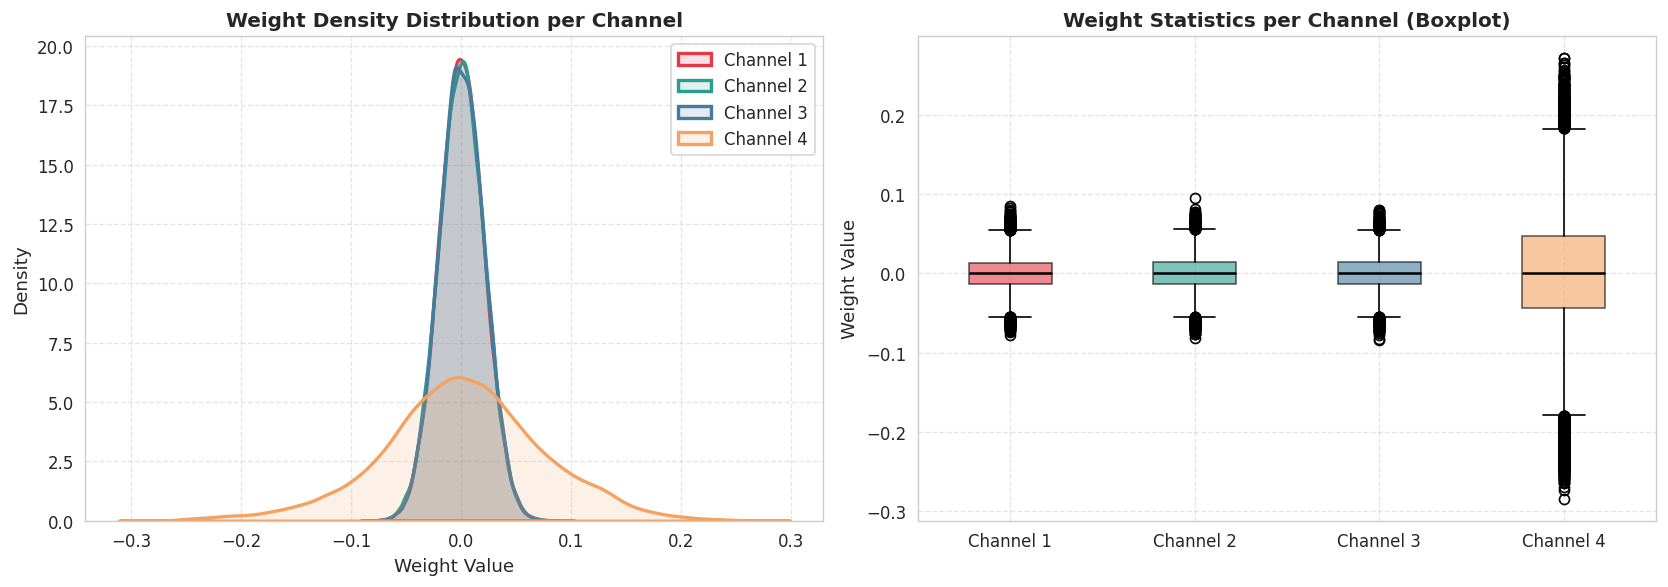


=== Weight Statistics Summary per Channel ===
Channel 1 -> Mean: -0.000133 | Std: 0.020349 | Min: -0.077829 | Max: 0.084612
Channel 2 -> Mean: -0.000137 | Std: 0.020581 | Min: -0.081324 | Max: 0.095248
Channel 3 -> Mean: 0.000070 | Std: 0.020412 | Min: -0.084335 | Max: 0.080014
Channel 4 -> Mean: 0.001255 | Std: 0.073922 | Min: -0.284289 | Max: 0.271643


In [10]:
model = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
print(model.encoder.embeddings.patch_embeddings.projection)

plot_vit_4channel_weights(model, layer_attr_name="encoder.embeddings.patch_embeddings.projection")

In [11]:
analyze_depth_channel_behavior(model, "encoder.embeddings.patch_embeddings.projection")

=== Channel Weight Statistics Comparison ===

Channel 1 (RGB):
  Mean: -0.000133
  Std:  0.020349
  Range: [-0.0778, 0.0846]
  IQR:  0.027446
  L2 Norm: 3.9476

Channel 2 (RGB):
  Mean: -0.000137
  Std:  0.020581
  Range: [-0.0813, 0.0952]
  IQR:  0.027776
  L2 Norm: 3.9927

Channel 3 (RGB):
  Mean: 0.000070
  Std:  0.020412
  Range: [-0.0843, 0.0800]
  IQR:  0.027510
  L2 Norm: 3.9598

Channel 4 (Depth):
  Mean: 0.001255
  Std:  0.073922
  Range: [-0.2843, 0.2716]
  IQR:  0.090506
  L2 Norm: 14.3423

=== Channel Contribution (Normalized L2 Norm) ===
Channel 1 (RGB): 15.0%
Channel 2 (RGB): 15.2%
Channel 3 (RGB): 15.1%
Channel 4 (Depth): 54.7%
  ⚠️  Depth channel has high contribution (54.7%), model may be over-relying on depth information


In [12]:
diagnose_channel_imbalance(model, "encoder.embeddings.patch_embeddings.projection")

=== Channel Balance Diagnosis ===
Channel means: ['-0.0001', '-0.0001', '0.0001', '0.0013']
Channel stds: ['0.0203', '0.0206', '0.0204', '0.0739']
RGB1 near-zero weight ratio: 37.87%
RGB2 near-zero weight ratio: 37.41%
RGB3 near-zero weight ratio: 37.35%
Depth near-zero weight ratio: 12.19%

RGB vs Depth Statistical Test:
  T-statistic: -5.4185
  P-value: 0.0000
  ✅ RGB and Depth weight distributions are significantly different (p<0.001)


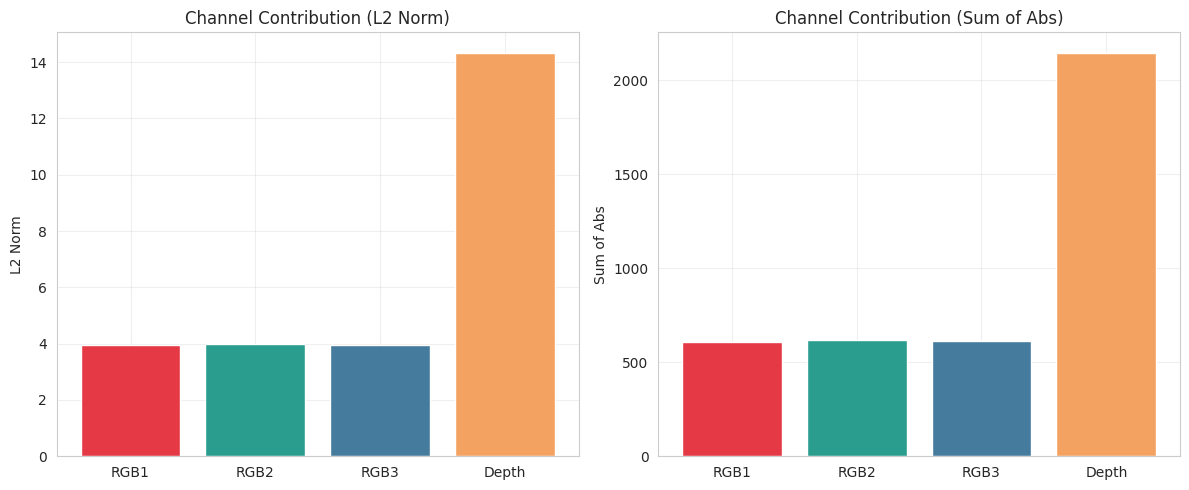

In [13]:
plot_channel_contribution(model, "encoder.embeddings.patch_embeddings.projection")